In [2]:
!git clone https://github.com/safouanb/airline-analytics



Cloning into 'airline-analytics'...
remote: Enumerating objects: 124, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (88/88), done.
remote: Total 124 (delta 56), reused 73 (delta 29), pack-reused 0 (from 0)
Receiving objects: 100% (124/124), 6.66 MiB | 5.97 MiB/s, done.
Resolving deltas: 100% (56/56), done.


In [3]:

import os
import re
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_classif


#Load and Organize Data IGNORE


In [3]:
df = pd.read_csv("/content/airline-analytics/data/raw/train.csv")
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

df.head(10)

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied
5,111157,Female,Loyal Customer,26,Personal Travel,Eco,1180,3,4,2,...,1,3,4,4,4,4,1,0,0.0,neutral or dissatisfied
6,82113,Male,Loyal Customer,47,Personal Travel,Eco,1276,2,4,2,...,2,3,3,4,3,5,2,9,23.0,neutral or dissatisfied
7,96462,Female,Loyal Customer,52,Business travel,Business,2035,4,3,4,...,5,5,5,5,4,5,4,4,0.0,satisfied
8,79485,Female,Loyal Customer,41,Business travel,Business,853,1,2,2,...,1,1,2,1,4,1,2,0,0.0,neutral or dissatisfied
9,65725,Male,disloyal Customer,20,Business travel,Eco,1061,3,3,3,...,2,2,3,4,4,3,2,0,0.0,neutral or dissatisfied


#Correlation Analysis IGNORE

In [4]:
# 1. Satisfaction binär kodieren
df["Satisfaction_binary"] = df["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})


In [ ]:
# 1. Use your existing binary target
target_col = "Satisfaction_binary"

# Quick check that it looks right
print(df[target_col].value_counts(dropna=False))

# 1 = satisfied, 0 = neutral/dissatisfied
# -> Higher correlation = more satisfaction when the feature is higher.

# 2. Select numeric columns (except the target)
import numpy as np
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

print("Numeric columns used for correlation:")
print(num_cols)

In [ ]:
# 2. Numerische Spalten auswählen (Id rauswerfen)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if "Id" in numeric_cols:
    numeric_cols.remove("Id")

In [ ]:
# 3. Korrelationsmatrix der numerischen Variablen
corr_matrix = df[numeric_cols].corr(method="pearson")

In [ ]:
# 4. Korrelation jeder numerischen Variable mit der Zielvariable
corr_with_target = corr_matrix["Satisfaction_binary"].drop("Satisfaction_binary")
corr_with_target_sorted = corr_with_target.reindex(
    corr_with_target.abs().sort_values(ascending=False).index
)
print("Korrelationen mit Satisfaction (absolut sortiert):")
print(corr_with_target_sorted)


In [ ]:
# 5. Heatmap der Korrelationsmatrix (optional: nur Service-Ratings)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0)
plt.title("Korrelationsmatrix numerischer Variablen")
plt.tight_layout()
plt.show()


In [ ]:

# 7. Bar chart of strongest correlations with Satisfaction

# Remove irrelevant variables
irrelevant = ["Id", "id", "ID"]
for col in irrelevant:
    if col in corr_with_target_sorted.index:
        corr_with_target_sorted = corr_with_target_sorted.drop(col)

plt.figure(figsize=(8, 6))
corr_with_target_sorted.plot(kind="bar")
plt.ylabel("Correlation coefficient with Satisfaction")
plt.title("Strength of Linear Relationship to Satisfaction")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Use your existing binary target
target_col = "Satisfaction_binary"

# Quick check that it looks right
print(df[target_col].value_counts(dropna=False))

# 1 = satisfied, 0 = neutral/dissatisfied
# -> Higher correlation = more satisfaction when the feature is higher.

# 2. Select numeric columns (except the target)
import numpy as np
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != target_col]

print("Numeric columns used for correlation:")
print(num_cols)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

def corr_by_group(data, group_col, target_col, num_cols):
    """
    Returns a DataFrame where:
      - rows   = numeric variables
      - cols   = each group value (e.g. Male, Female, Eco, Business)
      - values = Pearson correlation(feature, target) within that group
    """
    result = {}
    for g in data[group_col].dropna().unique():
        sub = data[data[group_col] == g]
        result[g] = sub[num_cols].corrwith(sub[target_col])
    return pd.DataFrame(result)

#Data Preparation IGNORE

In [ ]:
import pandas as pd
import numpy as np

# 1. Dataset balance
target_counts = df["Satisfaction_binary"].value_counts()
target_pct = df["Satisfaction_binary"].value_counts(normalize=True) * 100

print("Target distribution (Satisfied = 1):")
display(pd.DataFrame({"count": target_counts, "percentage": target_pct.round(2)}))

In [ ]:
# 2. Check constant / duplicate features (proof that feature selection is NOT needed)

constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
duplicate_cols = df.T[df.T.duplicated()].index.tolist()

print("Constant columns:", constant_cols)
print("Duplicate columns:", duplicate_cols)

if len(constant_cols) == 0 and len(duplicate_cols) == 0:
    print("\n➡️ No feature selection is required. All features contain useful information.")
else:
    print("\n⚠️ Some features would need removal.")

In [ ]:
# 3. Missing value detection
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values summary:")
display(missing)

In [ ]:
arrival_delay_median = df["Arrival Delay in Minutes"].median()
print("Mean of Arrival Delay in Minutes:", arrival_delay_median)

In [ ]:
df_imputed = df.copy()
df_imputed["Arrival Delay in Minutes"] = df_imputed["Arrival Delay in Minutes"].fillna(arrival_delay_median)

print("Missing values after imputation:")
print(df_imputed["Arrival Delay in Minutes"].isna().sum())

In [ ]:
import os

processed_path = "/content/airline-analytics/data/processed"
os.makedirs(processed_path, exist_ok=True)

In [ ]:
output_file = f"{processed_path}/train_processed.csv"
df_imputed.to_csv(output_file, index=False)

print("➡️ Processed file saved to:", output_file)

In [ ]:
# Variables expected to be on a 1–5 scale (or 0-5 in case of WiFi)
rating_cols = [
    "Inflight wifi service",
    "Departure/Arrival time convenient",
    "Ease of Online booking",
    "Gate location",
    "Food and drink",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Leg room service",
    "Baggage handling",
    "Checkin service",
    "Inflight service",
    "Cleanliness"
]

# Convert to the column names used in your df (if cleaned earlier)
rating_cols = [c for c in rating_cols if c in df.columns]

# Show wrong values for each 1–5 variable
wrong_values = {}

for col in rating_cols:
    unique_vals = df[col].unique()
    bad_vals = [v for v in unique_vals if v not in [0,1,2,3,4,5]]  # allow WiFi to have 0
    if len(bad_vals) > 0:
        wrong_values[col] = bad_vals

print("Columns with invalid values outside the 0–5 scale:")
wrong_values

#Data Modeling Gradient Tree

In [5]:
!python /content/airline-analytics/notebooks/preprocessing.py

In [6]:
# === RUN PREPROCESSING PIPELINE HERE ===

import pandas as pd
from pathlib import Path
import sys

# Make sure Python sees your notebooks folder
sys.path.append("/content/airline-analytics/notebooks")

from preprocessing import load_data, get_preprocessor

# 1. Load train.csv from data/raw
X, y = load_data("train.csv", data_dir="/content/airline-analytics/data/raw")

print("Raw dataset loaded:", X.shape)

# 2. Build preprocessing pipeline
preprocessor = get_preprocessor(X)

# 3. Fit + transform the training data
X_processed = preprocessor.fit_transform(X)

# 4. Build processed DataFrame with feature names

# Get numeric + ordinal columns
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
ordinal_cols = ['Class']
# Get one-hot encoded column names
ohe_cols = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(['Gender', 'Customer Type', 'Type of Travel'])
ohe_cols = list(ohe_cols)

new_columns = numeric_cols + ['Class_encoded'] + ohe_cols

df_processed = pd.DataFrame(X_processed, columns=new_columns)

# Add the target back
df_processed["Satisfaction_binary"] = y.values

# 5. SAVE processed dataset
output_dir = Path("/content/airline-analytics/data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "train_processed.csv"
df_processed.to_csv(output_path, index=False)

print("➡️ Saved processed dataset to:", output_path)

# 6. Quick check
print(df_processed.head())
print(df_processed.info())

Raw dataset loaded: (103904, 22)
➡️ Saved processed dataset to: /content/airline-analytics/data/processed/train_processed.csv
    Age  Flight Distance  Inflight wifi service  \
0  13.0            460.0                    3.0   
1  25.0            235.0                    3.0   
2  26.0           1142.0                    2.0   
3  25.0            562.0                    2.0   
4  61.0            214.0                    3.0   

   Departure/Arrival time convenient  Ease of Online booking  Gate location  \
0                                4.0                     3.0            1.0   
1                                2.0                     3.0            3.0   
2                                2.0                     2.0            2.0   
3                                5.0                     5.0            5.0   
4                                3.0                     3.0            3.0   

   Food and drink  Online boarding  Seat comfort  Inflight entertainment  ...  \
0          

In [7]:
import pandas as pd

# 1) Load processed data
df = pd.read_csv("/content/airline-analytics/data/processed/train_processed.csv")

df.head()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,...,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Class_encoded,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Satisfaction_binary
0,13.0,460.0,3.0,4.0,3.0,1.0,5.0,3.0,5.0,5.0,...,4.0,5.0,5.0,25.0,18.0,1.0,1.0,0.0,1.0,0
1,25.0,235.0,3.0,2.0,3.0,3.0,1.0,3.0,1.0,1.0,...,1.0,4.0,1.0,1.0,6.0,2.0,1.0,1.0,0.0,0
2,26.0,1142.0,2.0,2.0,2.0,2.0,5.0,5.0,5.0,5.0,...,4.0,4.0,5.0,0.0,0.0,2.0,0.0,0.0,0.0,1
3,25.0,562.0,2.0,5.0,5.0,5.0,2.0,2.0,2.0,2.0,...,1.0,4.0,2.0,11.0,9.0,2.0,0.0,0.0,0.0,0
4,61.0,214.0,3.0,3.0,3.0,3.0,4.0,5.0,5.0,3.0,...,3.0,3.0,3.0,0.0,0.0,2.0,1.0,0.0,0.0,1


In [8]:
# 2) Ensure Satisfaction_binary exists
if "Satisfaction_binary" not in df.columns:
    df["Satisfaction_binary"] = df["satisfaction"].map({
        "neutral or dissatisfied": 0,
        "satisfied": 1
    })

# Quick check
print(df["Satisfaction_binary"].value_counts())

Satisfaction_binary
0    58879
1    45025
Name: count, dtype: int64


In [9]:
# Target
y = df["Satisfaction_binary"]

# Features: drop the target column
X_encoded = df.drop(columns=["Satisfaction_binary"])

print("X_encoded shape:", X_encoded.shape)
print("y distribution:")
print(y.value_counts(normalize=True).round(3))

X_encoded shape: (103904, 22)
y distribution:
Satisfaction_binary
0    0.567
1    0.433
Name: proportion, dtype: float64


In [10]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

# Define the model
gbt = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# 5-fold cross-validation on the *training* data
cv_scores = cross_val_score(
    gbt,
    X_encoded,
    y,
    cv=5,               # 5 folds → each fold ~80/20 split
    scoring="accuracy"
)

print("Cross-validation accuracies per fold:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())
print("Std of CV accuracy:", cv_scores.std())

Cross-validation accuracies per fold: [0.94105192 0.94263991 0.93667292 0.94442038 0.94345525]
Mean CV accuracy: 0.9416480771401321
Std of CV accuracy: 0.0027218685935379377


In [11]:
gbt.fit(X_encoded, y)

GradientBoostingClassifier(learning_rate=0.05, n_estimators=200,
                           random_state=42)

In [12]:
from sklearn.model_selection import cross_val_score

# AUC per fold
cv_auc = cross_val_score(
    gbt,
    X_encoded,
    y,
    cv=5,
    scoring="roc_auc"
)

print("AUC values per fold:", cv_auc)
print("Mean AUC:", cv_auc.mean())
print("Std AUC:", cv_auc.std())

AUC values per fold: [0.98709126 0.98770176 0.98683378 0.98782466 0.98810069]
Mean AUC: 0.9875104313401362
Std AUC: 0.0004727186832042223


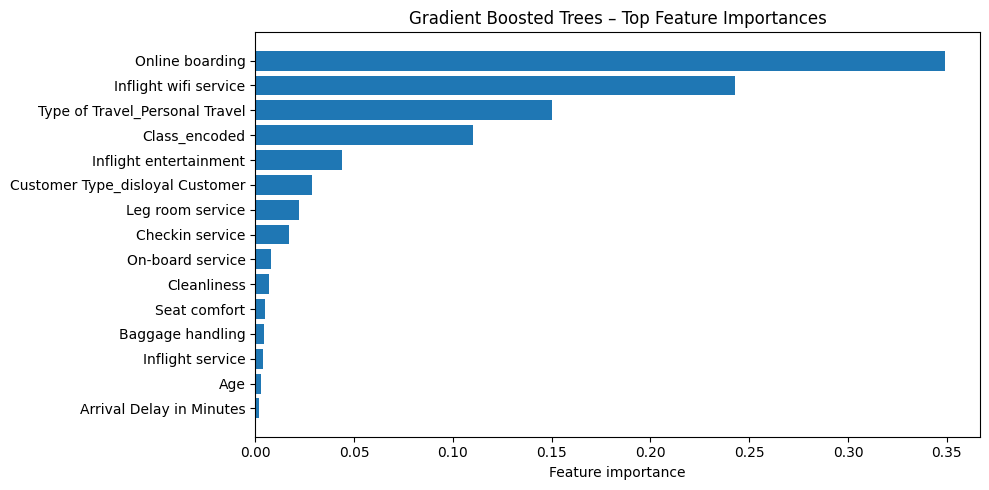

,feature,importance
7,Online boarding,0.349327
2,Inflight wifi service,0.242626
21,Type of Travel_Personal Travel,0.150190
18,Class_encoded,0.110049
9,Inflight entertainment,0.043776
20,Customer Type_disloyal Customer,0.028489
11,Leg room service,0.022142
13,Checkin service,0.017211
10,On-board service,0.007938
15,Cleanliness,0.006859


In [13]:

# (Optional) re-fit to be sure the model is trained on full data
gbt = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbt.fit(X_encoded, y)

# --- Get feature importances ---
importances = gbt.feature_importances_
feature_names = X_encoded.columns

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

# Sort by importance
fi = fi.sort_values("importance", ascending=False)

# Take top 15 (change number if you want more/less)
top_n = 15
fi_top = fi.head(top_n)

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.barh(fi_top["feature"][::-1], fi_top["importance"][::-1])
plt.xlabel("Feature importance")
plt.title("Gradient Boosted Trees – Top Feature Importances")
plt.tight_layout()
plt.show()

# Also display the table for reference
display(fi_top)

In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier

# Use encoded classes (0 = Eco, 1 = Eco Plus, 2 = Business)
classes = df["Class_encoded"].unique()
fi_dict = {}

for cls in classes:
    print(f"\n=== Training model for Class = {cls} ===")

    # subset to this travel class
    df_sub = df[df["Class_encoded"] == cls].copy()

    # target
    y_sub = df_sub["Satisfaction_binary"]

    # drop features we don't want to leak
    drop_cols = ["Satisfaction_binary", "Class_encoded"]
    X_sub = df_sub.drop(columns=drop_cols)

    # No one-hot encode needed — dataset already preprocessed!
    # All features are already numeric from the preprocessing pipeline.
    X_sub_enc = X_sub.copy()

    # train GBT with same hyperparams as before
    gbt_sub = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    gbt_sub.fit(X_sub_enc, y_sub)

    # feature importances
    fi_sub = pd.Series(
        gbt_sub.feature_importances_,
        index=X_sub_enc.columns,
        name=cls
    )

    # store
    fi_dict[cls] = fi_sub.sort_values(ascending=False)

    print("Top 10 features:")
    display(fi_dict[cls].head(10))


=== Training model for Class = 1.0 ===
Top 10 features:


,1.0
Inflight wifi service,0.810182
Type of Travel_Personal Travel,0.092119
Customer Type_disloyal Customer,0.023822
Online boarding,0.013178
Checkin service,0.012019
Arrival Delay in Minutes,0.010557
Baggage handling,0.009868
Age,0.007053
Inflight service,0.005464
Inflight entertainment,0.004697



=== Training model for Class = 2.0 ===
Top 10 features:


,2.0
Online boarding,0.375172
Inflight wifi service,0.148501
Inflight entertainment,0.096735
Type of Travel_Personal Travel,0.075230
Customer Type_disloyal Customer,0.071946
Leg room service,0.057373
Seat comfort,0.040029
Checkin service,0.037658
Cleanliness,0.020885
On-board service,0.018345



=== Training model for Class = 0.0 ===
Top 10 features:


,0.0
Inflight wifi service,0.872573
Type of Travel_Personal Travel,0.059213
Customer Type_disloyal Customer,0.028099
Arrival Delay in Minutes,0.008204
Checkin service,0.006520
Inflight entertainment,0.005337
Baggage handling,0.004243
Inflight service,0.004204
Ease of Online booking,0.003493
Online boarding,0.003031


In [15]:
import pandas as pd
import numpy as np

# Map encoded class values to readable names
class_map = {0: "Eco", 1: "Eco Plus", 2: "Business"}

# Combine all class-specific importances into one DataFrame
fi_all = pd.concat(fi_dict, axis=1)

# Rename columns from 0,1,2 → Eco, Eco Plus, Business
fi_all.columns = [class_map.get(c, str(c)) for c in fi_all.columns]

# Fill missing values with 0 (in case some features don't exist for a class)
fi_all = fi_all.fillna(0)

# Compute average importance to sort features
fi_all["Average_Importance"] = fi_all.mean(axis=1)
fi_all = fi_all.sort_values("Average_Importance", ascending=False)

# Show top 20 features with importance per class
fi_all_top20 = fi_all.head(20).drop(columns=["Average_Importance"])
print("Top 20 features with importance per travel class:")
display(fi_all_top20)

Top 20 features with importance per travel class:


,Eco Plus,Business,Eco
Inflight wifi service,0.810182,0.148501,0.872573
Online boarding,0.013178,0.375172,0.003031
Type of Travel_Personal Travel,0.092119,0.075230,0.059213
Customer Type_disloyal Customer,0.023822,0.071946,0.028099
Inflight entertainment,0.004697,0.096735,0.005337
Leg room service,0.000271,0.057373,0.000033
Checkin service,0.012019,0.037658,0.006520
Seat comfort,0.001100,0.040029,0.000036
Inflight service,0.005464,0.018237,0.004204
Baggage handling,0.009868,0.012626,0.004243


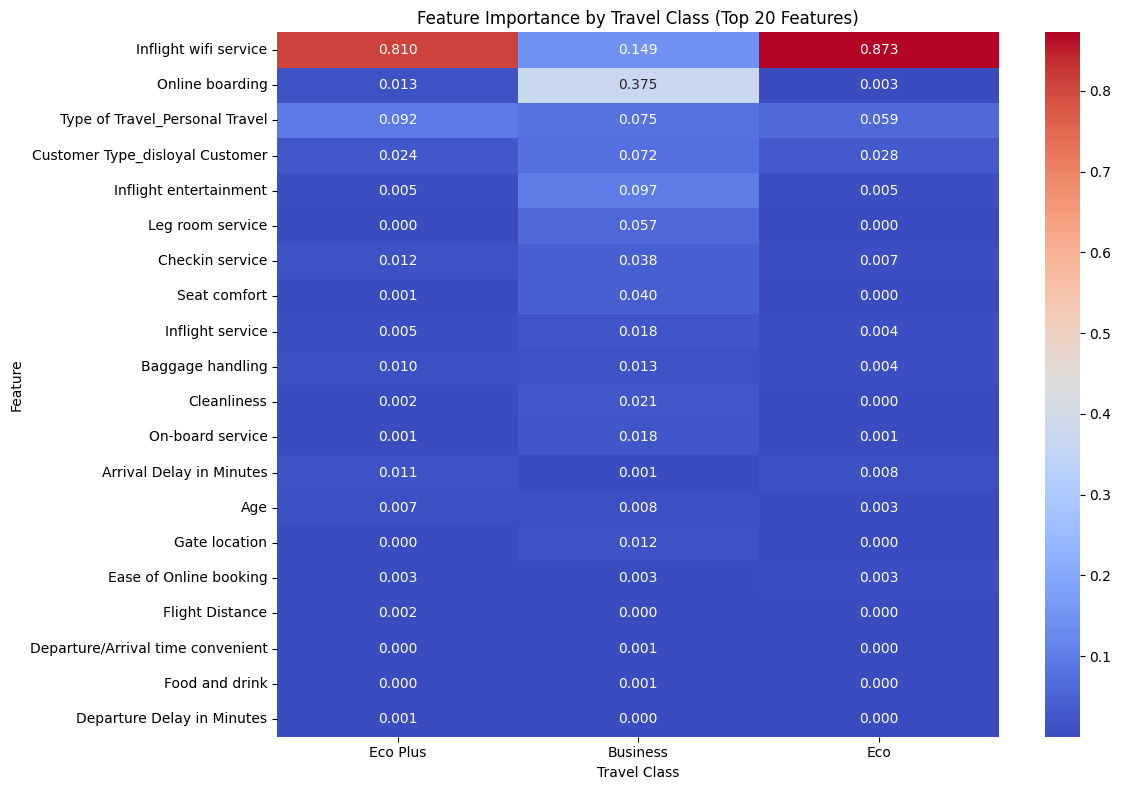

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(fi_all_top20, annot=True, fmt=".3f", cmap="coolwarm")
plt.title("Feature Importance by Travel Class (Top 20 Features)")
plt.xlabel("Travel Class")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

#Model with feature selection

In [19]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# 1) Train full model on ALL features
gbt_full = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbt_full.fit(X_encoded, y)

# 2) Get feature importances
importances = gbt_full.feature_importances_
feature_names = X_encoded.columns

fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("Top 15 features by importance:")
display(fi.head(15))

Top 15 features by importance:


,feature,importance
7,Online boarding,0.349327
2,Inflight wifi service,0.242626
21,Type of Travel_Personal Travel,0.150190
18,Class_encoded,0.110049
9,Inflight entertainment,0.043776
20,Customer Type_disloyal Customer,0.028489
11,Leg room service,0.022142
13,Checkin service,0.017211
10,On-board service,0.007938
15,Cleanliness,0.006859


In [20]:
from sklearn.metrics import accuracy_score, roc_auc_score

def eval_with_cv(X, y, model, cv=5):
    """Return mean accuracy and mean AUC from cross-validation."""
    acc_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    return acc_scores.mean(), acc_scores.std(), auc_scores.mean(), auc_scores.std()

In [21]:
acc_all_mean, acc_all_std, auc_all_mean, auc_all_std = eval_with_cv(
    X_encoded,
    y,
    gbt_full,
    cv=5
)

print("=== Baseline: ALL features ===")
print(f"Accuracy: {acc_all_mean:.4f} (± {acc_all_std:.4f})")
print(f"AUC:      {auc_all_mean:.4f} (± {auc_all_std:.4f})")

=== Baseline: ALL features ===
Accuracy: 0.9416 (± 0.0027)
AUC:      0.9875 (± 0.0005)


In [22]:
# select top 5 and top 7
top5_features = fi.head(5)["feature"].tolist()
top7_features = fi.head(7)["feature"].tolist()

X_top5 = X_encoded[top5_features]
X_top7 = X_encoded[top7_features]

def eval_model(X, y, cv=5):
    gbt = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    acc = cross_val_score(gbt, X, y, cv=cv, scoring="accuracy")
    auc = cross_val_score(gbt, X, y, cv=cv, scoring="roc_auc")
    return acc.mean(), acc.std(), auc.mean(), auc.std()

print("=== FULL MODEL RESULTS ===")
print(f"Accuracy: {cv_scores.mean():.4f}")
print(f"AUC:      {cv_auc.mean():.4f}")

print("\n=== TOP 5 MODEL ===")
acc5_mean, acc5_std, auc5_mean, auc5_std = eval_model(X_top5, y)
print(f"Accuracy: {acc5_mean:.4f} (± {acc5_std:.4f})")
print(f"AUC:      {auc5_mean:.4f} (± {auc5_std:.4f})")

print("\n=== TOP 7 MODEL ===")
acc7_mean, acc7_std, auc7_mean, auc7_std = eval_model(X_top7, y)
print(f"Accuracy: {acc7_mean:.4f} (± {acc7_std:.4f})")
print(f"AUC:      {auc7_mean:.4f} (± {auc7_std:.4f})")

=== FULL MODEL RESULTS ===
Accuracy: 0.9416
AUC:      0.9875

=== TOP 5 MODEL ===
Accuracy: 0.9092 (± 0.0019)
AUC:      0.9743 (± 0.0006)

=== TOP 7 MODEL ===
Accuracy: 0.9306 (± 0.0019)
AUC:      0.9810 (± 0.0006)


In [23]:
results = []

for k in range(3, 21):  # try 3…20 features
    topk = fi.head(k)["feature"].tolist()
    X_topk = X_encoded[topk]

    gbt_k = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    acc_mean = cross_val_score(gbt_k, X_topk, y, cv=5, scoring="accuracy").mean()
    results.append((k, acc_mean))

res_df = pd.DataFrame(results, columns=["k_features", "cv_accuracy"])
display(res_df)

best_row = res_df.loc[res_df["cv_accuracy"].idxmax()]
print(f"\nBest k: {int(best_row['k_features'])} with CV accuracy = {best_row['cv_accuracy']:.4f}")

,k_features,cv_accuracy
0,3,0.890736
1,4,0.897511
2,5,0.909166
3,6,0.927029
4,7,0.930609
5,8,0.932900
6,9,0.932794
7,10,0.934353
8,11,0.936287
9,12,0.939377



Best k: 19 with CV accuracy = 0.9418


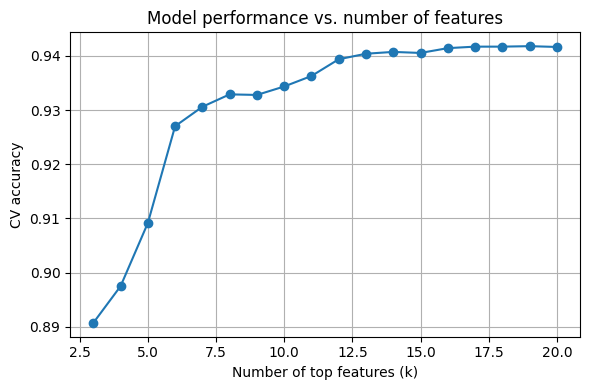

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(res_df["k_features"], res_df["cv_accuracy"], marker="o")
plt.xlabel("Number of top features (k)")
plt.ylabel("CV accuracy")
plt.title("Model performance vs. number of features")
plt.grid(True)
plt.tight_layout()
plt.show()